# Mean and Variance Propagation

### Application: Sewer Pipe Flow Velocity

We will apply Manning's formula for the flow velocity $V$ in a sewer:

$$
V =\frac{1}{n}R^{2/3}S^{1/2}
$$

where $R$ is the hydraulic radius of the sewer pipe (m), $S$ the slope of the pipe (m/m), and $n$ is Manning's roughness coefficient [$\mathrm{s}/\mathrm{m}^{1/3}$].

Both $R$ and $S$ are random variables, as it is known that sewer pipes are susceptible to deformations; $n$ is assumed to be deterministic and in our case $n=0.013$ $\mathrm{s}/\mathrm{m}^{1/3}$. The sewer pipe considered here has mean values $\mu_R$, $\mu_S$, and standard deviations $\sigma_R$ and $\sigma_S$; $R$ and $S$ are independent.

We are now interested in the mean flow velocity in the sewer as well as the uncertainty expressed by the standard deviation. This is important for the design of the sewer system.

*Disclaimer: the dimensions of the pipe come from a real case study, but some aspects of the exercise are...less realistic.*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.stats import probplot

import ipywidgets as widgets
from ipywidgets import interact

plt.rcParams.update({'font.size': 14})

### Theory: Propagation laws for a function of 2 random variables 

We are interested in the mean and variance of $X$, which is a function of 2 random variables: $X=q(Y_1,Y_2)$. The mean and covariance matrix of $Y$ are assumed to be known:

$$\mu_Y = [\mu_1\;\mu_2]^T$$

$$\Sigma_Y = \begin{bmatrix} \sigma^2_1 & Cov(Y_1,Y_2) \\ Cov(Y_1,Y_2) & \sigma^2_2\end{bmatrix}$$

The second-order Taylor series approximation of the mean $\mu_X$ is then given by:

$$\mu_X=\mathbb{E}(q(Y))\approx q(\mu_Y )+\frac{1}{2}\frac{\partial^2 q(\mu_Y )}{\partial Y_1^2 } \sigma_1^2+\frac{1}{2}\frac{\partial^2 q(\mu_Y )}{\partial Y_2^2 }\sigma_2^2+\frac{\partial^2 q(\mu_Y )}{\partial Y_1 \partial Y_2 } Cov(Y_1,Y_2) $$

In most practical situations, the second-order approximation suffices. 

For the variance $\sigma_X^2$ it is common to use only the first-order approximation, given by:

$$\sigma^2_X \approx \left(\frac{\partial q(\mu_Y )}{\partial Y_1 } \right)^2 \sigma^2_1 +\left(\frac{\partial q(\mu_Y )}{\partial Y_2 } \right)^2 \sigma^2_2 + 2\left(\frac{\partial q(\mu_Y )}{\partial Y_1 } \right) \left(\frac{\partial q(\mu_Y )}{\partial Y_2 } \right)  Cov(Y_1,Y_2)$$

## Part 1: Apply the Propagation Laws

We are interested to know how the uncertainty in $R$ and $S$ propagates into the uncertainty of the flow velocity $V$. We will first do this analytically and then implement it in code.

> **Task 1.1:**   
>
> Use the Taylor series approximation to find the expression for $\mu_V$ and $\sigma_V$ as function of $\mu_R$, $\sigma_R$, $\mu_S$, $\sigma_S$.

> **Task 1.2:**   
>
> Complete the function below, such that <code>moments_of_taylor_approximation</code> will compute the approximated $\mu_V$ and $\sigma_V$, as found in the previous Task.

In [ ]:
def moments_of_taylor_approximation(mu_R, mu_S, sigma_R, sigma_S,n):
    """Compute Taylor series approximation of mean and std of V.
    
    Take moments and function parameters as inputs (type float).
    Returns mean and standard deviation of V (type float).
    """
    
    constant = 1/n
    
    dVdR = (2/3) * (1 / n) * (mu_R**(-1/3)) * (mu_S**(1/2))
    dVdS = (1/2) * (1 / n) * (mu_R**(2/3)) * (mu_S**(-1/2))
    
    dVdR_2 = (-2/9) * (1 / n) * (mu_R**(-4/3)) * (mu_S**(1/2))
    dVdS_2 = (-1/4) * (1 / n) * (mu_R**(2/3)) * (mu_S**(-3/2))
    
    mu_V_0 = (1/ n) * (mu_R**(2/3)) * (mu_S**(1/2))
    mu_V = mu_V_0 + (1/2) * dVdR_2 * (sigma_R**2) + (1/2) * dVdS_2 * (sigma_S**2) #geen covariante term want independent variables
    
    var_V = (dVdR**2) * (sigma_R**2) + (dVdS**2) * (sigma_S**2) #geen covariante term want independent variables
    sigma_V = np.sqrt(var_V)
    
    return mu_V, sigma_V

Now we use the Taylor approximation and make two plots of $\sigma_V$ as a function of $\sigma_R$ for the following cases:
- $\sigma_S$ = 0.002 m/m
- $\sigma_S$ = 0 m/m (i.e., slope is deterministic, not susceptible to deformation)

We will use $\mu_R = 0.5$ m and $\mu_S = 0.015$ m/m, and vary $\sigma_R$ from 0 to 0.1 m. 

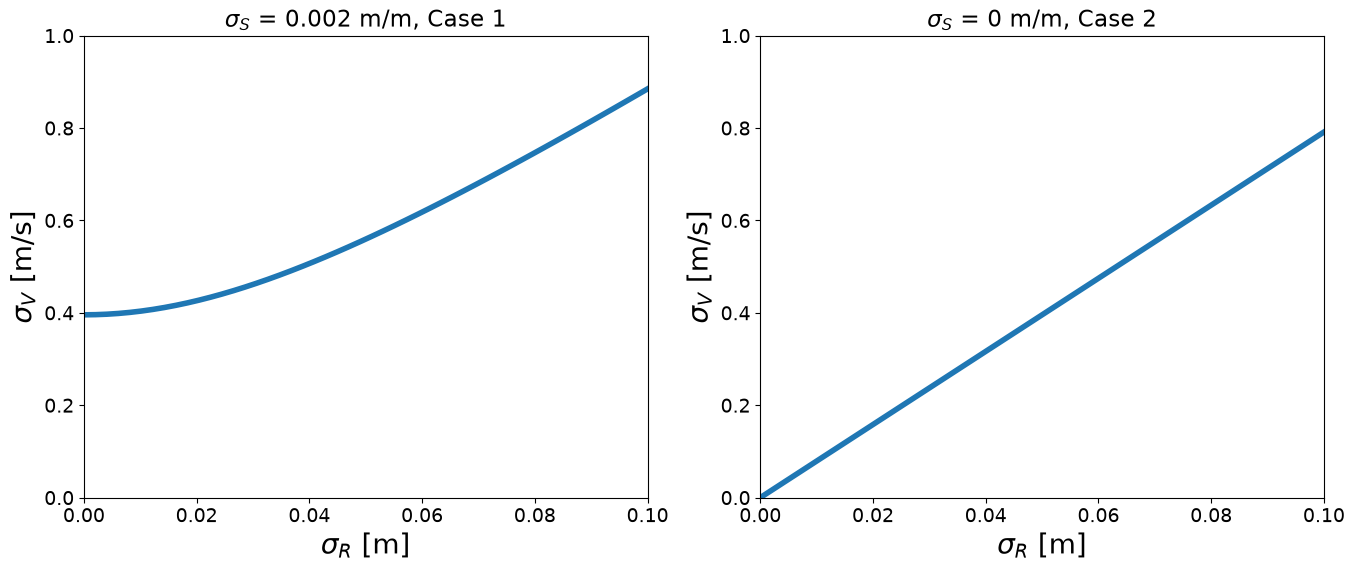

In [ ]:
n = 0.013
mu_R = 0.5
mu_S = 0.015
sigma_R = np.linspace(0.0, 0.1, 50)

# case 1 for sigma_S
sigma_S_1 = 0.002
mu_V_1, sigma_V_1 = moments_of_taylor_approximation(mu_R, mu_S, sigma_R, sigma_S_1, n)

# case 2 for sigma_S
sigma_S_2 = 0
mu_V_2, sigma_V_2 = moments_of_taylor_approximation(mu_R, mu_S, sigma_R, sigma_S_2, n)

fig, ax = plt.subplots(1, 2, figsize = (16, 6))
# left side plot for case 1 
ax[0].plot(sigma_R, sigma_V_1, linewidth=4)
ax[0].set_ylabel(r'$\sigma_V$ [m/s]', size = 20)
ax[0].set_xlabel(r'$\sigma_R$ [m]', size = 20)
ax[0].set_title(r'$\sigma_S$ = ' + f'{sigma_S_1} m/m, Case 1')
ax[0].set_xlim(0, 0.1)
ax[0].set_ylim(0, 1)
# right side plot for case 2
ax[1].plot(sigma_R, sigma_V_2, linewidth=4)
ax[1].set_ylabel(r'$\sigma_V$ [m/s]', size = 20)
ax[1].set_xlabel(r'$\sigma_R$ [m]', size = 20)
ax[1].set_title(r'$\sigma_S$ = ' + f'{sigma_S_2} m/m, Case 2')
ax[1].set_xlim(0, 0.1)
ax[1].set_ylim(0, 1)
plt.show()

> **Task 1.3:**   
> Interpret the figures above, specifically looking at differences between Case 1 and Case 2. Look at the equations you derived to understand why for Case 1 we get a non-linear relation, and for Case 2 a linear one.

## Part 2: Simulation-Based Propagation 

We will use again the following values:
- $\mu_R = 0.5$ m
- $\mu_S = 0.015$ m/m
- $\sigma_R=0.05$ m
- $\sigma_S=0.002$ m/m

It is assumed that $R$ and $S$ are independent and normally distributed random variables. We will generate at least 10,000 simulated realizations each of $R$ and $S$ using a random number generator, and then use these to calculate the corresponding sample values of $V$ to find the moments of that sample.


### A Note on "Sampling"

We will use Monte Carlo Simulation to create an empirical "sample" of the random values of our function of random variables, $V$ (the output). This is a commonly used approach widely used in science and engineering applications. It is a numerical way of computing the distribution of a function that is useful when analytic approaches are not possible (for example, when the input distributions are non-Normal or the function is non-linear). For our purposes today, Monte Carlo Simulation is quite simple and involves the following steps:

1. Define a function of random variables and the distributions of its input parameters.
2. Create a random sample of each input parameter according to the specified distribution.
3. Create a random sample of the output variable by computing the function for every set of input samples.
4. Evaluate the resulting distribution of the output.

A few key points to recognize are:
1. As the sample size increases, the resulting distribution becomes more accurate.
2. This is a way to get the (approximately) "true" distribution of a function of random variables.
3. Accuracy is relative to the propagation of uncertainty through the function based on the assumed distributions of the input random variables. In other words, MCS can't help you if your function and distributions are poor representations of reality!

$R$ and $S$ are modelled as Gaussian random variables; non-positive simulated values are rejected and resampled to respect their physical domain.


> **Task 2.1:** 
>
> Complete the functions <code>function_of_random_variables</code> and <code>get_samples</code> below to define the function of random variables and then:
> - Generate a sample of the output from this function, assuming the inputs are also random variables with the Normal distribution. 
> - Find the moments of the samples.

In [ ]:
def function_of_random_variables(R, S, n):
    V = (1/n) * (R**(2/3)) * (S**(1/2))
    return V

def get_samples(N, sigma_R, mu_R=0.5, mu_S=0.015, sigma_S=0.002, n=0.013):
    """Generate random samples for V from R and S."""
    R = np.random.normal(mu_R, sigma_R, N)
    S = np.random.normal(mu_S, sigma_S, N)

    # Resample non-physical values.
    while np.any(R <= 0):
        mask = R <= 0
        R[mask] = np.random.normal(mu_R, sigma_R, mask.sum())
    while np.any(S <= 0):
        mask = S <= 0
        S[mask] = np.random.normal(mu_S, sigma_S, mask.sum())

    V = function_of_random_variables(R, S, n)
    return V

V_samples = get_samples(10000, 0.05)

mu_V_samples = np.mean(V_samples)
sigma_V_samples = np.std(V_samples)

print('Moments of the SAMPLES:')
print(f'  {mu_V_samples:.4f} m/s is the mean, and')
print(f'  {sigma_V_samples:.4f} m/s is the std dev.')

mu_V_taylor, sigma_V_taylor = moments_of_taylor_approximation(mu_R, mu_S, 0.05, 0.002, n)
print('\nMoments of the TAYLOR SERIES APPROXIMATION:')
print(f'  {mu_V_taylor:.4f} m/s is the mean, and')
print(f'  {sigma_V_taylor:.4f} m/s is the std dev.')


Moments of the SAMPLES:
  5.8823 m/s is the mean, and
  0.8856 m/s is the std dev.

Moments of the TAYLOR SERIES APPROXIMATION:
  5.9151 m/s is the mean, and
  0.5596 m/s is the std dev.


> **Task 2.2:**
>    
> Are the results similar for the linearized and simulated values? Describe the difference quantitatively. Check your result also for the range of values of $\sigma_R$ from 0.01 to 0.10; are they consistent?

> **Task 2.3:**  
>
> Run the cell with the sampling algorithm above repeatedly and look at the values printed in the cell output. Which values change? Which values do <em>not</em> change? Explain why, in each case.

## Part 3: Validating the Moments with a Distribution

In Part 2 we used a sample of the function of random variables to _validate_ the Taylor approximation. Now we will assume that the function of random variables has a Normal distribution and compare it with the simulated sample.

We will also use a normal probability plot to assess how well the assumption that $V$ is normally distributed holds while varying $\sigma_R$.

### Theoretical Quantiles with `probplot`

The method `probplot` from `scipy.stats` compares ordered samples with theoretical quantiles of a chosen distribution. For a Normal distribution, the horizontal axis contains standard-Normal quantiles $q$, while the vertical axis contains the ordered samples of $V$. If $V\sim\mathcal{N}(\mu_V,\sigma_V^2)$, then

$$
V_q=\mu_V+q\sigma_V,
$$

so the points approximately follow a straight line. With `fit=True`, `probplot` adds a fitted reference line; this line is not a PDF. Systematic departures from the line indicate deviations from Normality, especially in the tails.


> **Task 3.1:**
>
> Complete the function `validate_distribution` below (instructions are in the docstring) to plot the empirical probability density function (PDF) of $V$ using your simulated samples. Also plot the Normal PDF in the same figure using the moments computed from the error propagation law. 
>
> *Hint: if you are struggling with the code below, re-read the introduction to Part 3 carefully!*

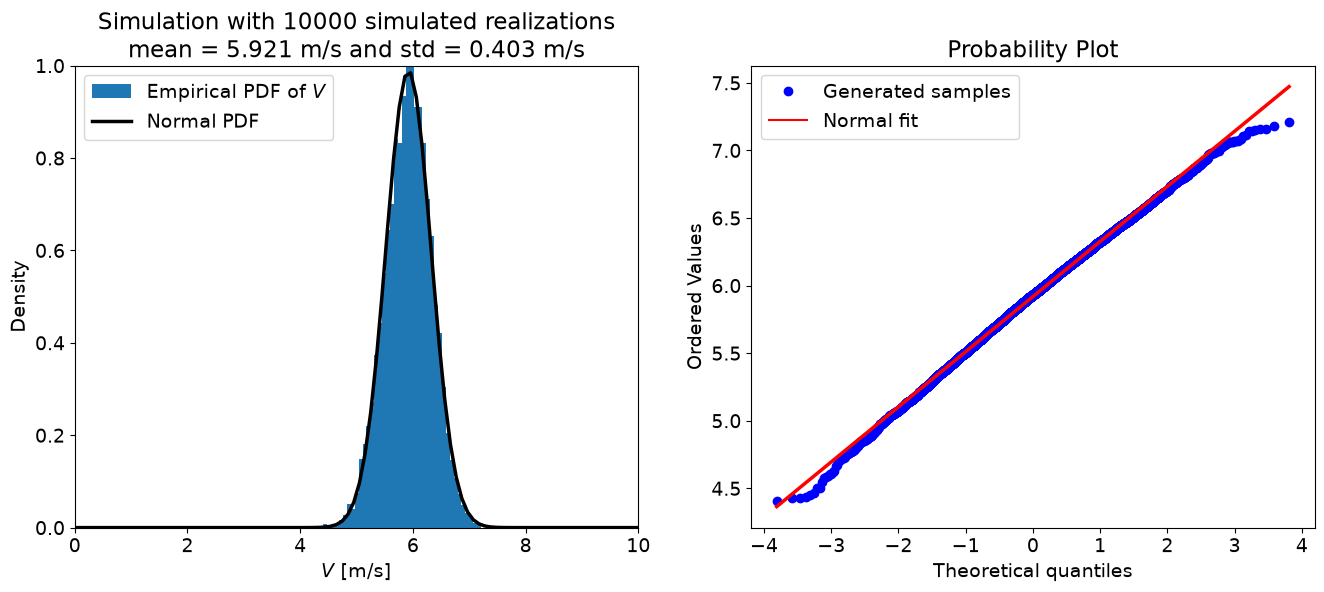

In [ ]:
def validate_distribution(N, sigma_R, mu_R=0.5, mu_S=0.015, sigma_S=0.002, n=0.013):
    """Generate samples and plots for V."""

    # Generate a sample and compute moments
    V_samples = get_samples(N, sigma_R)
    mu_V_samples = np.mean(V_samples)
    sigma_V_samples = np.std(V_samples)

    # Compute moments using Taylor
    mu_V_taylor, sigma_V_taylor = moments_of_taylor_approximation(mu_R, mu_S, sigma_R, sigma_S, n)

    xmin = 0
    xmax = 10
    x = np.linspace(xmin, xmax, 100)
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    ax[0].hist(V_samples, bins=40, density=True,
               label='Empirical PDF of $V$')

    ax[0].plot(
        x,
        norm.pdf(x, mu_V_taylor, sigma_V_taylor),
        color='black',
        lw=2.5,
        label='Normal PDF'
    )

    ax[0].legend()
    ax[0].set_xlabel('$V$ [m/s]')
    ax[0].set_xlim(xmin, xmax)
    ax[0].set_ylim(0, 1)
    ax[0].set_ylabel('Density')
    ax[0].set_title(
        f'Simulation with {N} simulated realizations'
        + '\n'
        + f'mean = {mu_V_taylor:.3f} m/s and '
        + f'std = {sigma_V_taylor:.3f} m/s'
    )

    probplot(V_samples, dist=norm, fit=True, plot=ax[1])

    ax[1].legend(['Generated samples', 'Normal fit'])
    ax[1].get_lines()[1].set_linewidth(2.5)
    plt.show()

validate_distribution(10000, 0.01)


### Validate the Distribution of $V$ for Various $\sigma_R$

The code below uses a widget to call your function to make the plots and add a slider to change the values of $\sigma_R$ and visualize the change in the distributions.

> **Task 3.2:**
>
> Run the cell below, then play with the slider to change $\sigma_R$. How well does the error propagation law match the "true" distribution (the samples)? State your conclusion and explain why. Check also whether there is an impact for different $\sigma_R$ values.

In [ ]:
@interact(sigma_R=(0, 0.1, 0.005))
def samples_slideplot(sigma_R):
    validate_distribution(50000, sigma_R);

> **Task 3.3:**
>
> From the probability plot, estimate the standardized quantile $|q|$ beyond which the simulated distribution noticeably deviates from the Normal approximation. Then compute the corresponding two-sided probability $P(|Z|>|q|)$, where $Z=(V-\mu_V)/\sigma_V$.
>
> *Hint: $P(|Z|>|q|)=2\Phi(-|q|)$, where `scipy.stats.norm.cdf` evaluates $\Phi$.*


> **Note:**
>
> The Normal distribution does not fit the tails perfectly. The calculation in Task 3.3 is therefore intended only to estimate the order of magnitude of the tail probability.


In [ ]:
p = ### YOUR CODE HERE ###

print(f'The probability is {p:0.6e}')

> By Lotfi Massarweh and Sandra Verhagen, Delft University of Technology. CC BY 4.0, more info on the Credits page of Workbook. 